In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

# Classificador

In [2]:
def matriz_conf(y_true, y_pred, labels):
    total_labels = labels
    print(total_labels)
    cm = np.zeros((len(total_labels),len(total_labels)), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i]][y_pred[i]] += 1
    
    cm = pd.DataFrame(cm, columns=total_labels, index=total_labels)

    cm_transp = pd.DataFrame(np.transpose(cm.to_numpy()), columns=total_labels, index=total_labels)

    for c in cm_transp.columns:
        cm_transp[c] = cm_transp[c]/cm_transp[c].sum()

    cm_porcento = pd.DataFrame(np.transpose(cm_transp.to_numpy()), columns=total_labels, index=total_labels)

    return cm, cm_porcento

def acc(cm, hidden_classes):
    cm_transp = pd.DataFrame(np.transpose(cm.dropna().to_numpy()), columns=cm.columns, index=cm.columns)
    acc = 0
    total = 0
    for c in cm_transp.columns:
        if c not in hidden_classes:
            acc += cm_transp[c][c]
        else:
            acc += cm_transp[c][-1]
        total += cm_transp[c].sum()
    return acc/total

# Calcula CM para todos

In [2]:
filenames = [0,2,3,4,5]

labels_str = ['DDoS', 'Benign', 'DoS', 'BruteForce', 'Bot', 'Web']

filenames

# pd.set_option('future.no_silent_downcasting', True)

[0, 2, 3, 4, 5]

In [10]:
train_encoded_df = pd.read_csv(f'test_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{0}_hidden.csv')
train_encoded_df['Label'].unique()

array([ 0.,  1., nan,  4.,  2.,  3.,  5.])

0


Label
1    514148
2    329224
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


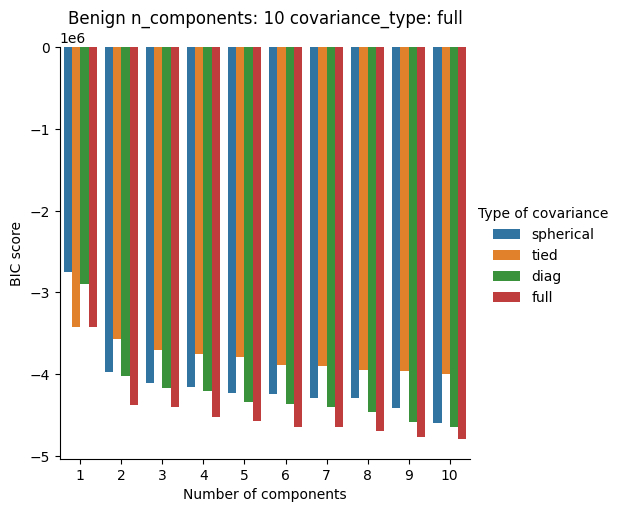

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


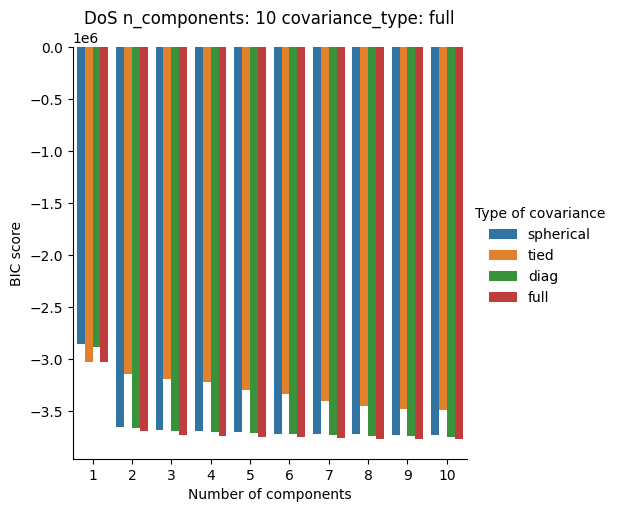

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


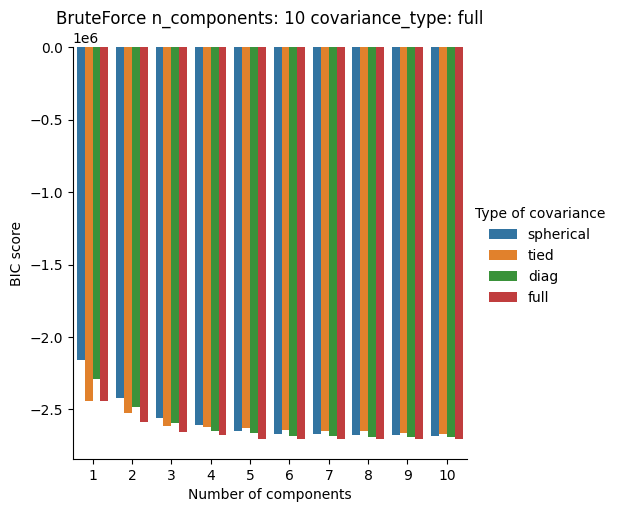

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


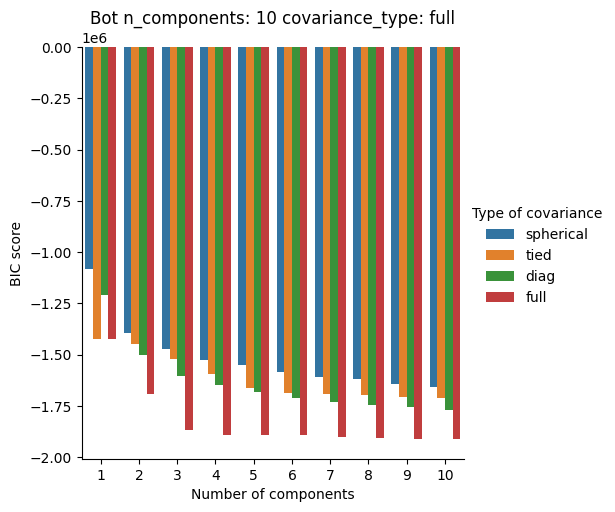

Tipo: 5 = Web
Melhor modelo: n_componentes: 6 covariance_type: full


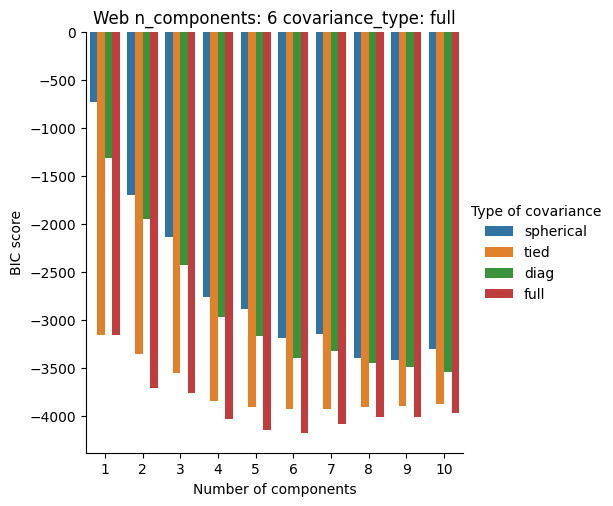

,0,1,2,3,4,5
0,NaN,19.935705,-48.818030,-15808.303205,-21.500241,-65.854462
1,NaN,-8.412854,29.685671,17.478867,-320.092369,-158.010622
2,NaN,24.235509,-36.801325,-14968.220023,-20.034179,-37.640116
3,NaN,-102.669033,-52.032445,26.650458,-974.547268,-195.489090
4,NaN,27.129415,-17.689401,-15496.922456,-15.503954,-0.599197
...,...,...,...,...,...,...
519951,NaN,24.848032,-30.161328,-15479.226154,-18.381144,-26.695069
519952,NaN,4.697448,-172.079922,-35874.640927,27.759064,-18.744434
519953,NaN,18.034682,-8.887314,-17512.429612,-23.359146,-1.604396
519954,NaN,26.376891,-4.701878,-14893.066887,-15.588237,8.495412


,0,1,2,3,4,5
0,NaN,15.782865,-10.579611,-19533.749084,-21.725941,-1.939594
1,NaN,19.983174,-48.667244,-15830.178252,-21.850692,-65.868764
2,NaN,17.791645,-29.584972,-15032.525547,-27.892576,-35.347519
3,NaN,21.651181,-30.298690,-15290.989247,-19.190273,-29.453321
4,NaN,10.113548,-50.882997,-14946.087469,-38.142500,-88.554959
...,...,...,...,...,...,...
649942,NaN,27.072268,-17.271194,-15536.595487,-16.133043,-0.589151
649943,NaN,8.571452,-50.371799,-15441.953821,-37.192937,-88.991128
649944,NaN,9.479708,-50.812048,-15183.309777,-37.443595,-88.622713
649945,NaN,-98.805963,-59.466125,28.227133,-952.318874,-222.030006


2


Label
0    808919
1    514148
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


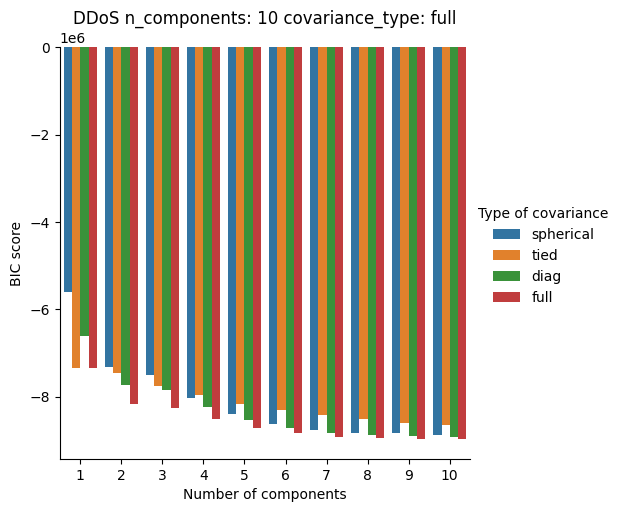

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


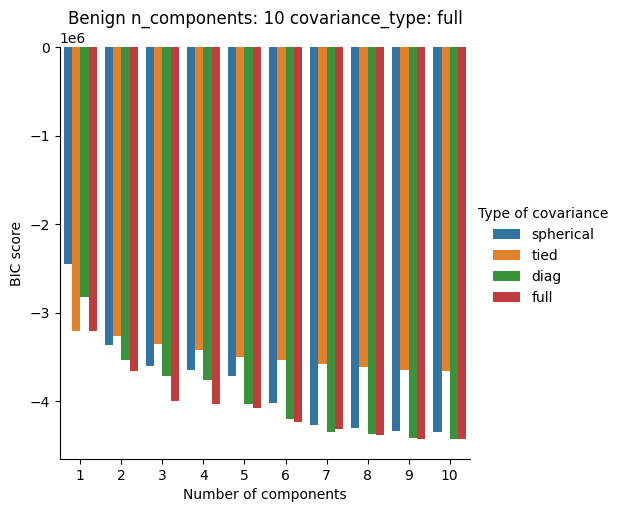

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


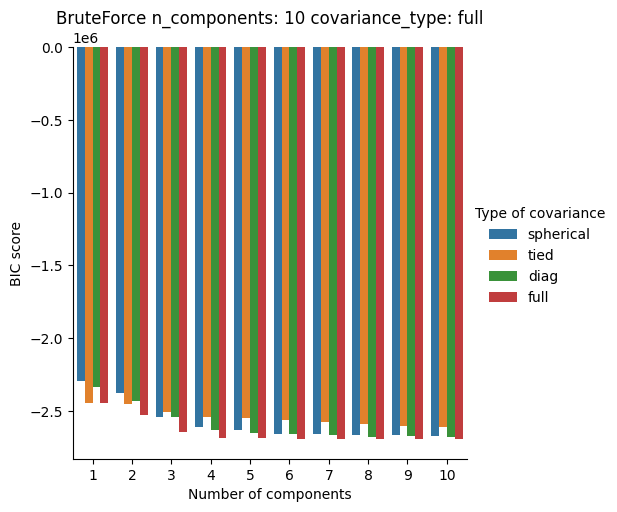

Tipo: 4 = Bot
Melhor modelo: n_componentes: 9 covariance_type: full


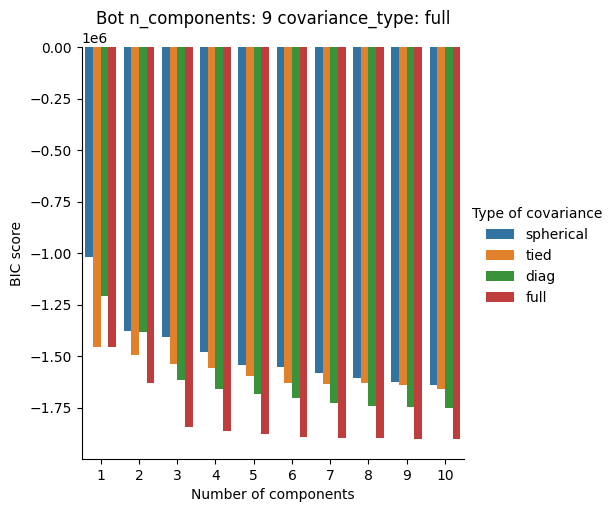

Tipo: 5 = Web
Melhor modelo: n_componentes: 6 covariance_type: full


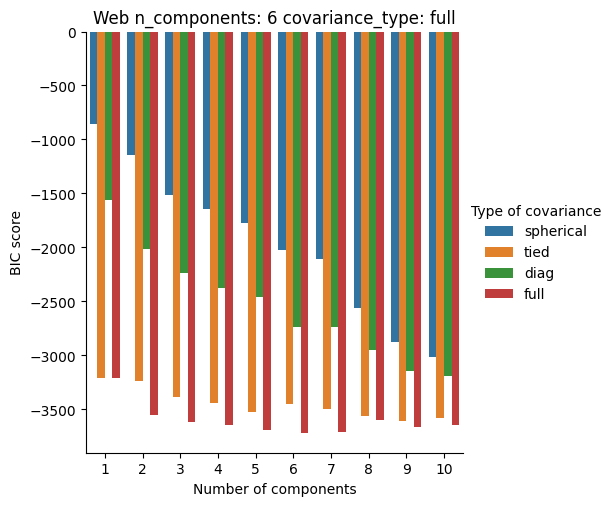

,0,1,2,3,4,5
0,27.853626,1.228241,NaN,-771.849489,-11.246005,11.248075
1,-127.472456,8.091937,NaN,10.937964,6.426105,-19.922661
2,-22.752563,21.396545,NaN,-229.666183,-3.358800,-8.193467
3,-1549.475777,-18.314796,NaN,26.564266,-80.161634,-14.824745
4,-23.122721,25.785711,NaN,-110.845490,-7.568887,-30.946506
...,...,...,...,...,...,...
519951,-9.876669,22.908966,NaN,-242.649377,5.433757,-3.389218
519952,-1233.450819,-12.288260,NaN,-762.279719,27.757749,5.066249
519953,29.036097,-0.371385,NaN,-879.464631,-12.207645,5.229718
519954,-14.957209,22.823879,NaN,-182.889337,0.645002,-12.278379


,0,1,2,3,4,5
0,29.036326,-0.358534,NaN,-879.284898,-12.179944,5.295871
1,27.602446,1.131471,NaN,-775.062633,-11.419837,11.149400
2,-9.933000,18.114528,NaN,-250.857270,5.144849,-5.690370
3,-11.687664,17.948089,NaN,-246.896483,5.827942,-2.997627
4,27.380589,-0.436602,NaN,-800.412777,-8.549417,8.889816
...,...,...,...,...,...,...
649942,-23.299747,25.683687,NaN,-110.006838,-7.715271,-30.892867
649943,26.553994,-0.539943,NaN,-801.758200,-8.797627,8.528735
649944,27.369877,-0.502324,NaN,-802.234142,-8.687447,8.741682
649945,-1520.485656,-17.766586,NaN,28.138395,-79.941378,-17.397068


3


Label
0    808919
1    514148
2    329224
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


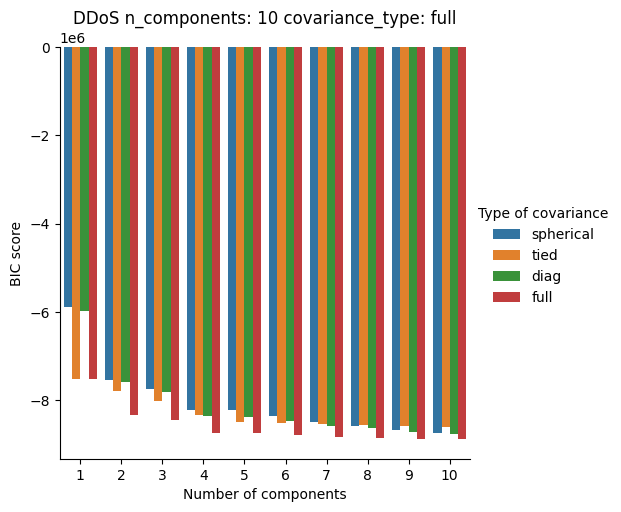

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


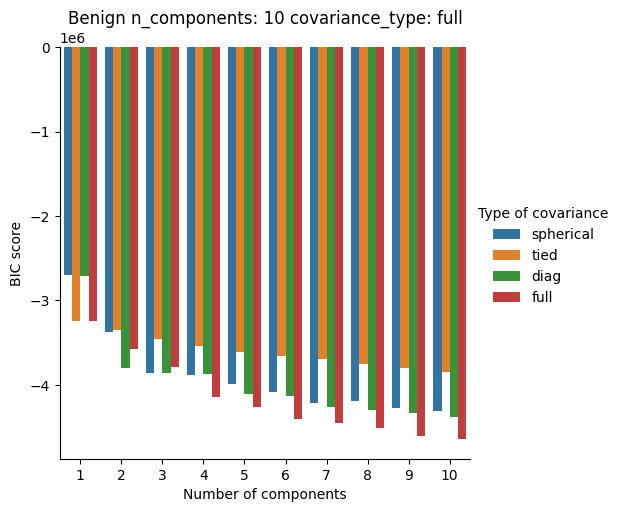

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


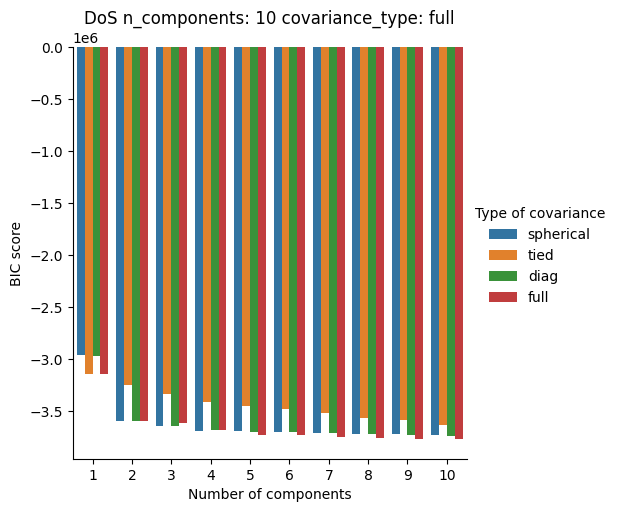

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


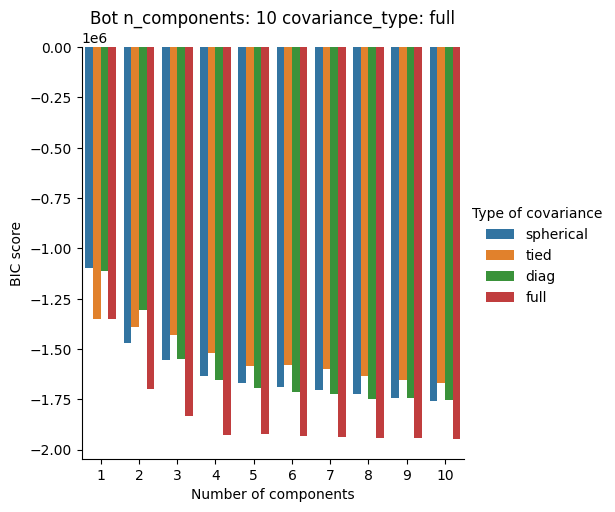

Tipo: 5 = Web
Melhor modelo: n_componentes: 9 covariance_type: full


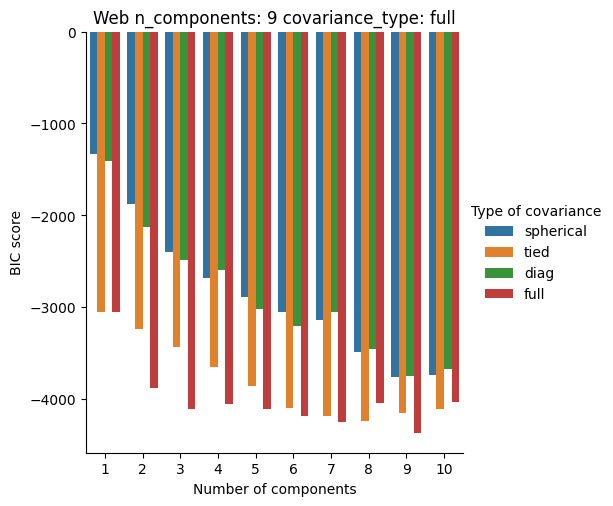

,0,1,2,3,4,5
0,27.834727,4.162283,-723.604943,NaN,-3.665202,-69.125475
1,-634.326950,-11.051835,29.577303,NaN,-94.649758,-290.929802
2,-81.057923,20.877818,-49.918325,NaN,-20.629879,-6.063244
3,-495.570785,-4.070697,14.488868,NaN,-48.587136,-212.936928
4,-18.587011,25.598044,-29.912319,NaN,-7.913972,5.453818
...,...,...,...,...,...,...
519951,-44.846790,23.800083,-35.411936,NaN,-8.807356,0.548878
519952,-3212.562284,6.069623,-1722.752299,NaN,28.632486,-32.961569
519953,28.519073,5.795755,-705.838754,NaN,0.843066,-26.139132
519954,-21.811885,24.874003,-29.935703,NaN,-11.146927,6.754267


,0,1,2,3,4,5
0,28.398259,5.812859,-700.451409,NaN,0.919235,-22.458321
1,27.527981,4.115589,-725.618304,NaN,-3.721215,-72.996709
2,-64.035491,21.086736,-45.948998,NaN,-16.180052,-3.282802
3,-45.177776,24.273473,-36.139165,NaN,-9.338404,1.013433
4,26.786963,2.653891,-766.084254,NaN,-5.564714,-64.594387
...,...,...,...,...,...,...
649942,-18.718784,25.594613,-29.929370,NaN,-7.941481,5.447689
649943,25.686879,2.574487,-770.575205,NaN,-5.625801,-71.161090
649944,26.905589,2.648665,-764.327218,NaN,-5.542333,-64.335891
649945,-888.996060,-31.575279,-2.491791,NaN,-223.842079,-487.037411


4


Label
0    808919
1    514148
2    329224
3    243806
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


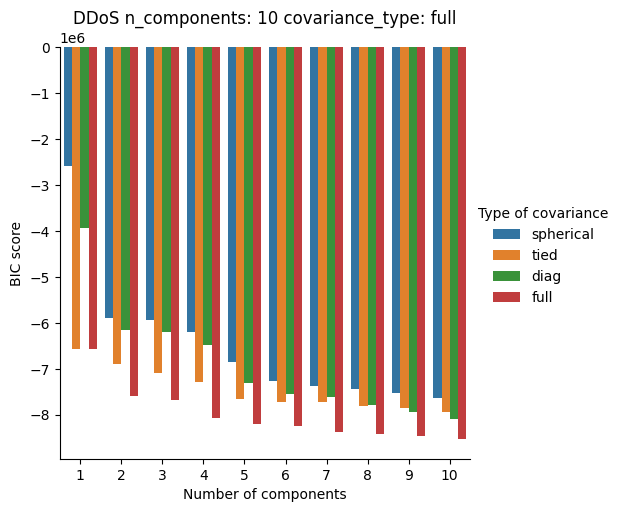

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


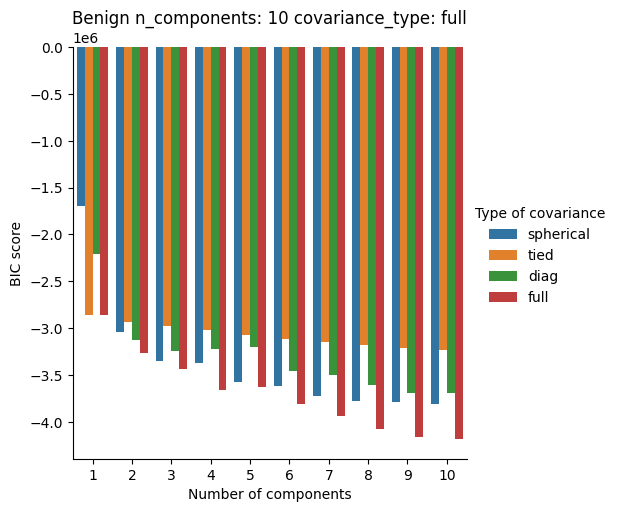

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


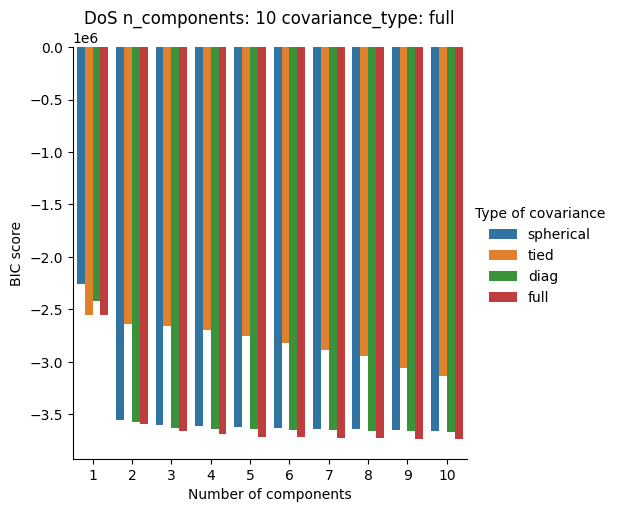

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


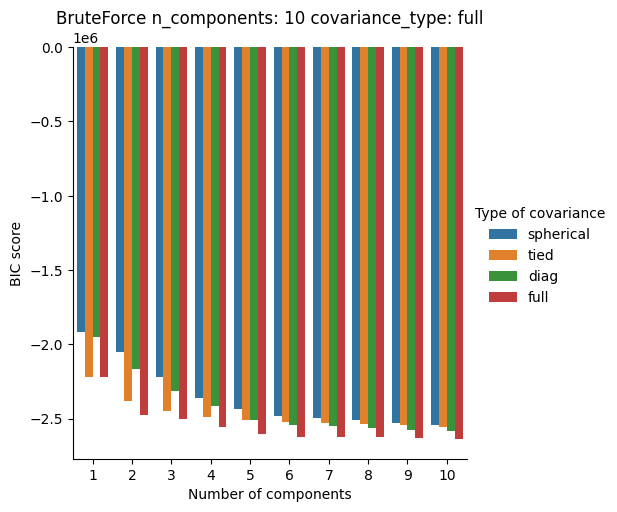

Tipo: 5 = Web
Melhor modelo: n_componentes: 8 covariance_type: full


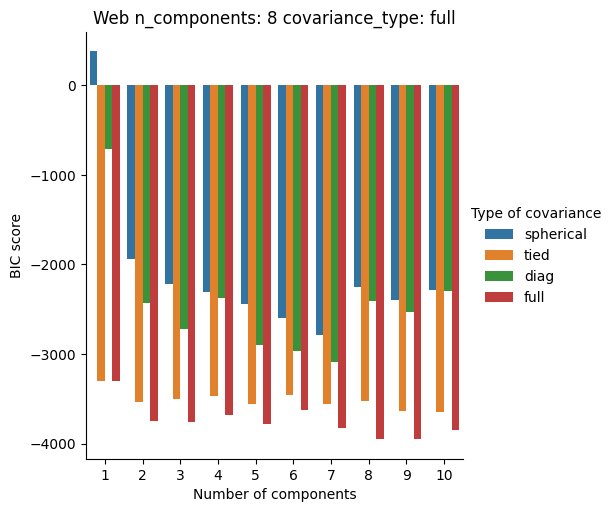

,0,1,2,3,4,5
0,27.623404,0.172728,-193.923771,-2221.695100,NaN,-33.332047
1,-204.759144,2.051410,29.666263,12.646799,NaN,-488.527134
2,-217.815041,21.077081,-39.225226,-583.676970,NaN,-334.044915
3,-234.447844,-10.617840,-10.395063,26.595794,NaN,-820.714566
4,-138.519312,23.771325,-38.116815,-645.399148,NaN,-284.272170
...,...,...,...,...,...,...
519951,-141.061831,22.380533,-37.045827,-618.160768,NaN,-321.981002
519952,-127.594230,18.438309,-42.929166,-1088.344170,NaN,-199.949615
519953,26.967464,0.404284,-280.941552,-2526.259259,NaN,4.251894
519954,-274.334099,21.427230,-91.637857,-649.886392,NaN,-383.023017


,0,1,2,3,4,5
0,26.501692,0.556979,-280.061273,-2518.591395,NaN,4.729285
1,27.189657,0.142870,-194.122774,-2224.753923,NaN,-33.399980
2,-234.315275,14.048238,-34.661007,-587.940197,NaN,-304.154264
3,-186.110203,12.192911,-39.369615,-626.427518,NaN,-310.556083
4,25.638025,0.335179,-225.073289,-2505.599950,NaN,-54.348411
...,...,...,...,...,...,...
649942,-137.813457,23.967702,-38.250789,-646.200121,NaN,-285.428379
649943,26.964300,0.404274,-224.537317,-2504.298183,NaN,-53.975523
649944,27.161332,0.379743,-224.783691,-2505.071120,NaN,-54.527650
649945,-307.886550,-11.816833,-6.555724,26.357975,NaN,-1077.268239


5


Label
0    808919
1    514148
2    329224
3    243806
4    183163
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


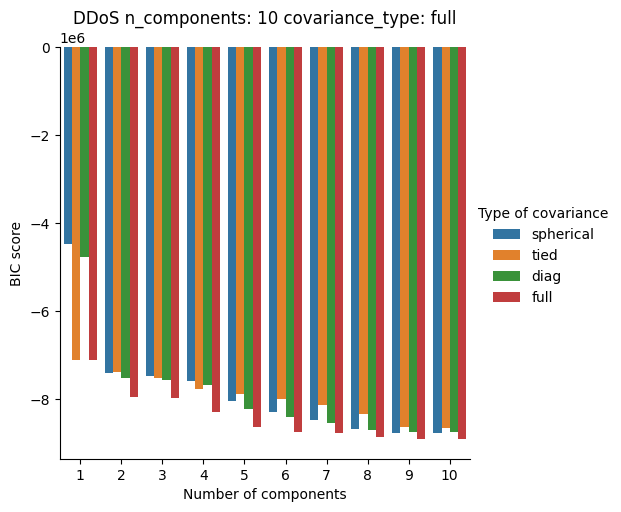

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


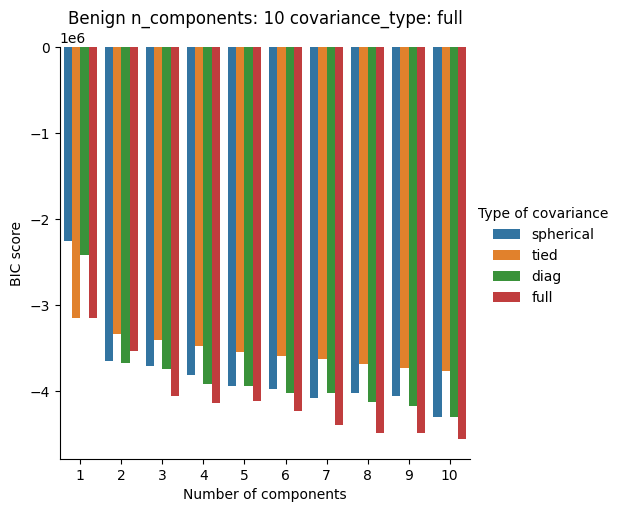

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


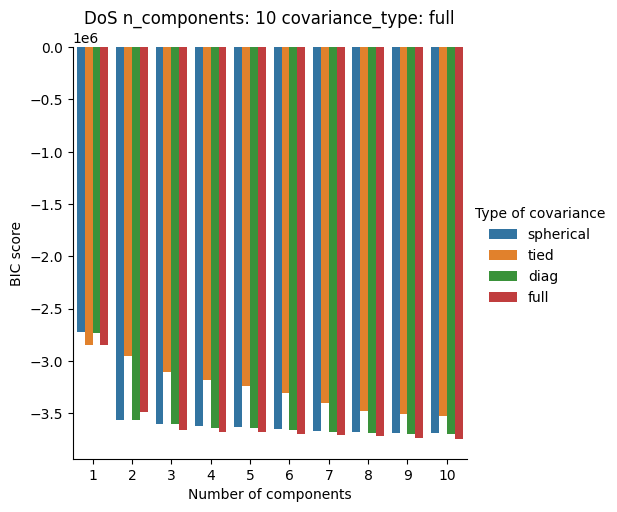

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


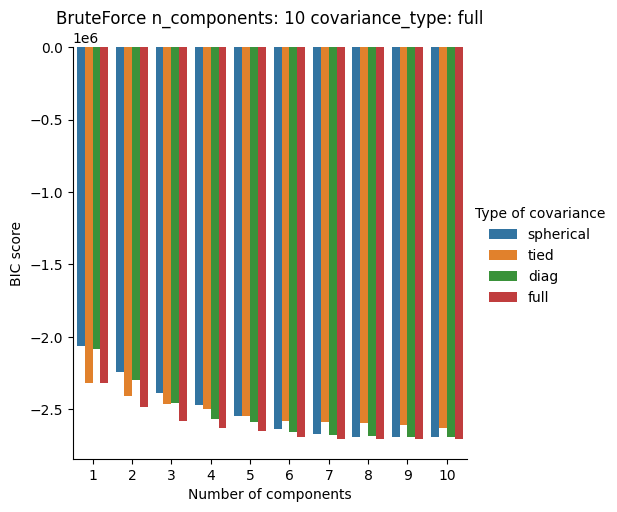

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


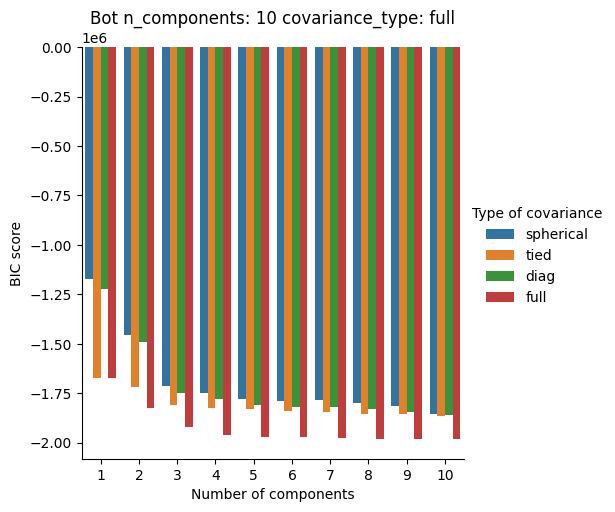

,0,1,2,3,4,5
0,27.810569,-0.981456,-708.859362,-21015.620735,7.536300,NaN
1,-747.985920,-31.417626,29.613657,17.517898,-3346.774515,NaN
2,-18.427531,22.424825,-185.677306,-5572.567230,-6.566223,NaN
3,-2284.379987,-41.494032,-313.446116,27.706110,-7897.460947,NaN
4,-11.889307,28.573834,-197.629182,-5301.086119,-7.984960,NaN
...,...,...,...,...,...,...
519951,-8.681786,26.165429,-184.877698,-5327.479825,10.717322,NaN
519952,6.484263,3.411956,-365.173643,-10782.871686,27.054117,NaN
519953,28.638756,-0.136420,-706.623085,-21096.494017,3.419918,NaN
519954,-7.233794,23.654961,-216.123925,-5578.552030,-24.009238,NaN


,0,1,2,3,4,5
0,28.333657,-0.253615,-708.040801,-21145.737707,3.693131,NaN
1,27.786751,-1.247162,-708.705510,-21005.907364,7.448968,NaN
2,-16.196890,21.724915,-186.530369,-5224.344121,0.055987,NaN
3,-9.589710,23.260664,-188.112730,-5123.804697,11.214098,NaN
4,24.085546,-32.946624,-711.574343,-20627.779671,-2.228060,NaN
...,...,...,...,...,...,...
649942,-11.786983,28.542299,-197.275687,-5311.279462,-7.576570,NaN
649943,26.603397,-34.748919,-717.450750,-20832.786359,-1.690197,NaN
649944,27.337143,-34.213062,-716.111005,-20816.840586,-2.217049,NaN
649945,-2278.664703,-42.160226,-326.027642,27.283179,-8386.050521,NaN


In [5]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import os

def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 11),
    "covariance_type": ["spherical", "tied", "diag", "full"],
    "random_state": [123],
}

exp_train = []
exp_val = []
exp_test = []
y_true_all_exp_train = []
y_true_all_exp_val = []
y_true_all_exp_test = []
for z in range(len(filenames)):
    
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    val_encoded_df = pd.read_csv(f'val_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    test_encoded_df = pd.read_csv(f'test_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    y_true_all_exp_train.append(train_encoded_df['Label'].values.tolist())
    y_true_all_exp_val.append(val_encoded_df['Label'].values.tolist())
    y_true_all_exp_test.append(test_encoded_df['Label'].values.tolist())
    print(filenames[z])
    hidden_classes = [filenames[z]] # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        val_encoded_df['Label'] = val_encoded_df['Label'].replace(labels_str[i],i)
        test_encoded_df['Label'] = test_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
        
    
        
    gmms = []
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Tipo: {i} = {labels_str[i]}')
            grid_search = GridSearchCV(
                GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
            )
            grid_search.fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
            print(f"Melhor modelo: n_componentes: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            gmms.append(grid_search.best_estimator_)
            df = pd.DataFrame(grid_search.cv_results_)[
                ["param_n_components", "param_covariance_type", "mean_test_score"]
            ]
            df["mean_test_score"] = -df["mean_test_score"]
            df = df.rename(
                columns={
                    "param_n_components": "Number of components",
                    "param_covariance_type": "Type of covariance",
                    "mean_test_score": "BIC score",
                }
            )
            df.sort_values(by="BIC score").head()
            sns.catplot(
                data=df,
                kind="bar",
                x="Number of components",
                y="BIC score",
                hue="Type of covariance",
                
            ).set(title = f"{labels_str[i]} n_components: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            plt.show()
            # plt.savefig(f'class_{i}_train_{filenames[z]}_GMM_BIC_1_10_scores.png')
        else:
            gmms.append(None)
    
    # scores = []
    # for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
    #     max_dist = -np.inf
    #     pred = -1
    #     scores.append([])
    #     for j in range(len(labels_str)):
    #         if j not in hidden_classes:
    #             inside = False
    #             max = -np.inf
    #             # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
    #             score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
    #             scores[i].append(score)
    #         else:
    #             scores[i].append(np.nan)
    
    
    # display(pd.DataFrame(scores))
    # exp_train.append(scores)
    #pd.DataFrame(scores).to_csv(f'train_{filenames[z]}_GMM_BIC_1_10_scores.csv',index=False)

    scores = []
    for i, row in val_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_val.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = val_encoded_df["Label"].values
    scores_df.to_csv(f'val_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)

    scores = []
    for i, row in test_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_test.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = test_encoded_df["Label"].values
    scores_df.to_csv(f'test_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)